<div>
<a href="https://www.audiolabs-erlangen.de/fau/professor/mueller"><img src="data_layout/PCP_Teaser.png" width=100% style="float: right;" alt="PCP Teaser"></a>
</div>

# Unit 5: Visualization Using Matplotlib

<ul>
    <li><a href='#learn' style="color:#E65100;"><strong>Overview and Learning Objectives</strong></a></li>      
    <li><a href="#matplotlib" style="color:black;">Introducing Matplotlib</a></li>
    <li><a href="#background_visualization" style="color:#1B5E20;"><strong>Background:</strong> From Numbers to Visual Insight</a></li>
    <li><a href="#line_plot" style="color:black;">Line Plots and Sampled Data</a></li>
    <li><a href="#background_sampling" style="color:#1B5E20;"><strong>Background:</strong> Continuous Functions and Discrete Samples</a></li>
    <li><a href="#subplots" style="color:black;">Comparing Plotting Styles with Subplots</a></li>
    <li><a href="#vis2D" style="color:black;">Visualizing Two-Dimensional Arrays</a></li>
    <li><a href="#vis2D_details" style="color:black;">Coordinates, Display Limits, and Color Scaling</a></li>
    <li><a href='#vis3D' style="color:black;"> Three-Dimensional Surface Plots</a></li>
    <li><a href='#exercise_vis1D' style="color:#006064;"><strong>Exercise 1:</strong> Visualizing a Sampled Sinusoid</a></li>
    <li><a href='#exercise_circle' style="color:#006064;"><strong>Exercise 2:</strong> Approximating a Circle with Samples</a></li>    
    <li><a href='#exercise_logaxis' style="color:#006064;"><strong>Exercise 3:</strong> Comparing Linear and Logarithmic Axes</a></li>
    <li><a href='#exercise_erlangen' style="color:#006064;"><strong>Exercise 4:</strong> Manipulating a Digital Photograph</a></li>      
</ul>

<a id="learn"></a>
<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">

<h2 style="color:#E65100; margin-top:0;">
Overview and Learning Objectives
</h2>

<p style="color:#E65100;">
Visualization transforms numerical values into figures in which patterns, relationships, and unexpected features can be easier to recognize. It is therefore an essential tool in data science, multimedia engineering, and signal processing. This unit introduces <a href="https://matplotlib.org/">Matplotlib</a>, a widely used Python library for creating scientific figures. We begin with line plots and sampled data, continue with two-dimensional arrays and images, and conclude with three-dimensional surface plots. The learning objectives are:
</p>

<ul style="color:#E65100;">
<li>Create line plots from NumPy arrays and understand how Matplotlib represents discrete samples visually.</li>
<li>Design informative figures using titles, axis labels, legends, grids, colors, markers, and suitable axis limits.</li>
<li>Arrange and compare several visualizations using subplots and different plotting styles.</li>
<li>Choose between linear and logarithmic axes according to the range and meaning of the displayed values.</li>
<li>Visualize two-dimensional arrays and control their colormap, origin, aspect ratio, coordinate extent, visible region, and color scale.</li>
<li>Represent sampled functions of two variables using color-coded images and three-dimensional surfaces.</li>
<li>Load, inspect, display, manipulate, and save digital images represented as NumPy arrays.</li>
</ul>

<p style="color:#E65100;">
The unit contains four hands-on exercises:
</p>

<ul style="color:#E65100;">
<li><a href="#exercise_vis1D">Exercise 1</a>: Visualize a sampled sinusoid using line, stem, step, and bar plots.</li>
<li><a href="#exercise_circle">Exercise 2</a>: Approximate a circle using sampled sine and cosine values and investigate the effects of sampling and axis scaling.</li>
<li><a href="#exercise_logaxis">Exercise 3</a>: Compare linear and logarithmic horizontal and vertical axes.</li>
<li><a href="#exercise_erlangen">Exercise 4</a>: Load, analyze, and creatively modify a digital photograph represented as a NumPy array.</li>
</ul>

<p style="color:#E65100; margin-bottom:0;">
Visualization will accompany many later units, particularly those concerning complex exponentials, sampled signals, and Fourier analysis. Further examples can be found in the <a href="https://matplotlib.org/stable/gallery/index.html">Matplotlib gallery</a>, which includes executable plotting examples, and the <a href="https://www.audiolabs-erlangen.de/FMP">FMP Notebooks</a>, which contain numerous visualizations from audio and music processing.
</p>

</div>

In [1]:
# --- Core scientific stack ---
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# --- Custom utilities (Unit 5) ---
from libpcp.unit05 import (
    exercise_vis1D,
    exercise_circle,
    exercise_logaxis,
    exercise_erlangen,
)

# --- SVG figure output and font-size settings ---
%config InlineBackend.figure_formats = ['svg']
plt.rcParams.update({'font.size': 8, 'axes.titlesize': 9,})

<a id="matplotlib"></a>
## Introducing Matplotlib

[Matplotlib](https://matplotlib.org/) is a widely used Python library for creating scientific visualizations. It can produce line plots, scatter plots, images, surface plots, and many other kinds of figures. These figures can be displayed interactively in a Jupyter notebook or saved in formats such as PNG, SVG, and PDF. This unit uses the module [`matplotlib.pyplot`](https://matplotlib.org/stable/api/pyplot_summary.html), which provides the functions needed to create and modify figures. Following the usual convention, we imported it earlier using the abbreviation `plt`. We also imported NumPy as `np` for constructing and processing the numerical data to be visualized.

Python provides several ways to explore the available plotting functions. The function `dir(plt)` returns a list containing the names available in the module, while `help()` displays documentation for a selected function. For example, `help(plt.plot)` describes the function used to create line plots. Within a Jupyter notebook, the question-mark syntax `plt.plot?` provides similar information. Since Matplotlib contains many functions and the resulting documentation may be long, we do not display it here. In practice, the searchable [Matplotlib documentation](https://matplotlib.org/stable/) and its [gallery of examples](https://matplotlib.org/stable/gallery/index.html) are particularly useful when looking for a suitable plot or plotting option.

<a id="background_visualization"></a>
<div style="
  background-color: #C8E6C9A0;
  border: 1px solid #81C784A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">

<h2 style="color:#1B5E20; margin-top:0;">
Background: From Numbers to Visual Insight
</h2>

<p style="color:#1B5E20;">
The familiar saying that <strong>a picture is worth a thousand words</strong> is particularly appropriate in data analysis and signal processing. A signal may contain millions of samples, and an image may contain millions of pixel values. Although the numbers contain the information, inspecting them individually rarely reveals much. A suitable figure can make important structures visible at a glance. Different numerical objects naturally suggest different visual representations. A <strong>line plot</strong> may reveal silence, oscillations, impulses, or changes in the amplitude of a signal. An <strong>image</strong> maps values to spatial positions and colors, making shapes, edges, and textures visible. A <strong>surface</strong> can show how a quantity depends on two variables. When the data consist of separate items, a <strong>scatter plot</strong> represents each item as a point and may reveal groups, trends, outliers, or relationships between measured properties.
</p>

<div style="
  float:right;
  width:200px;
  max-width:45%;
  margin-left:20px;
  margin-bottom:10px;
">
<img src="data/PCP_fig_mandelbrot.png"
     style="display:block; width:100%; height:auto;"
     alt="Visualization of the Mandelbrot set">
</div>

<p style="color:#1B5E20;">
Visualization can also make abstract mathematical objects accessible. A set of numbers, for example, may be represented by marking the positions of its elements in a coordinate system. A particularly striking example is the <a href="https://en.wikipedia.org/wiki/Mandelbrot_set"><strong>Mandelbrot set</strong></a>, a subset of the complex plane defined by repeatedly applying a simple mathematical rule. Each point in the image corresponds to a complex number, and its color indicates the behavior of the associated iteration. The exact set contains infinitely fine detail and cannot be drawn completely. A computer instead examines a finite grid of complex numbers and performs a limited number of iterations. The resulting image is only an approximation, yet it reveals an elaborate fractal boundary in which increasingly fine structures appear under magnification. We will return to this example in <a href="PCP_06_complex.html">Unit 6</a>, where a simple numerical procedure will produce this surprisingly intricate picture.
</p>

<p style="color:#1B5E20; margin-bottom:0;">
Visualizations can accompany every stage of an analysis: the original signal or image, an intermediate transformation, an extracted feature, or the final result. Different figures may also reveal different aspects of the same data. A waveform emphasizes change over time, a histogram shows the distribution of values, and a frequency-domain representation obtained using the discrete Fourier transform exposes oscillatory structure. <strong>A good scientific figure is therefore more than decoration</strong>. It helps us explore data, check calculations, discover unexpected behavior, and communicate results. Matplotlib provides the tools, but choosing what to show remains our responsibility. <strong>A picture may be worth a thousand words, but only when it is the right picture</strong>.
</p>

<div style="clear:both;"></div>
</div>

<a id="line_plot"></a>
## Line Plots and Sampled Data

We begin with one of the most basic and widely used visualizations: the **line plot**. A line plot represents pairs of numerical values as points in a coordinate system and connects neighboring points with line segments. It is particularly useful for showing how one quantity changes with another, such as the amplitude of a signal over time or the value of a mathematical function over its input variable.

To construct a line plot, Matplotlib needs two arrays of equal length. The first contains the horizontal coordinates, and the second contains the corresponding vertical values. In the following example, we use sampled values of the sine and cosine functions over the interval from $-\pi$ to $\pi$. The array `t` contains 256 equally spaced angles, including both endpoints, while `f_cos` and `f_sin` contain the corresponding function values.

The function `plt.figure()` creates a new figure. Its size is specified in inches using `figsize=(width, height)`, while `layout='tight'` automatically adjusts the spacing around the plotting area. Each call to `plt.plot()` adds a line to the current figure. Matplotlib selects suitable colors and axis limits automatically:

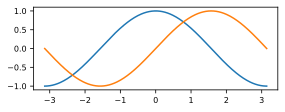

In [2]:
# Compute the sampled function values
t = np.linspace(-np.pi, np.pi, 256, endpoint=True)
f_cos = np.cos(t)
f_sin = np.sin(t)

# Plot both functions in the same figure
plt.figure(figsize=(4, 1.6), layout='tight')
plt.plot(t, f_cos)
plt.plot(t, f_sin)

For every index `n`, the two calls plot the pairs `(t[n], f_cos[n])` and `(t[n], f_sin[n])`. Matplotlib connects neighboring points with straight segments, which appear smooth because the 256 sampling positions are closely spaced. Jupyter may also display output such as `[<matplotlib.lines.Line2D at 0x...>]`. This is not an error but a representation of the line object returned by `plt.plot()`. Adding a semicolon to the final command, as in `plt.plot(t, f_sin);`, suppresses this textual output without affecting the figure.

The default settings provide a quick view of the data. A scientific figure, however, should give readers enough information to understand what is shown without inspecting the plotting code. The next example uses the same data and introduces several important ways to control the figure:

* `color`, `linewidth`, and `linestyle` control the appearance of a line.
* `label` names a line, while `plt.legend()` displays the assigned names.
* `plt.title()`, `plt.xlabel()`, and `plt.ylabel()` describe the figure and its axes.
* `plt.xlim()` and `plt.ylim()` determine the visible ranges.
* `plt.xticks()` and `plt.yticks()` control the tick positions and labels.
* `plt.savefig()` saves the completed figure to a file.

Matplotlib provides many additional formatting options, which can be explored in the documentation for [`plt.plot()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html) and the other plotting functions when needed. In the following example, meaningful tick labels, descriptive axis labels, a legend, and carefully selected visual properties make the figure easier to interpret and help communicate its main content clearly:


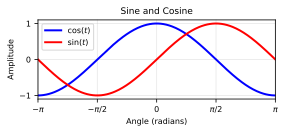

In [3]:
plt.figure(figsize=(4, 1.9), layout='tight')

plt.plot(t, f_cos, color='blue', linewidth=2, label=r'$\cos(t)$')
plt.plot(t, f_sin, color='red', linewidth=2, label=r'$\sin(t)$')

plt.title('Sine and Cosine')
plt.xlabel('Angle (radians)')
plt.ylabel('Amplitude')
plt.xlim(-np.pi, np.pi)
plt.ylim(-1.1, 1.1)
plt.xticks(
    [-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi],
    [r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'],
)
plt.yticks([-1, 0, 1])
plt.grid(alpha=0.3)
plt.legend(loc='upper left')

# The output directory must already exist
output_path = os.path.join('output', 'Figure_CosSin.png')
plt.savefig(output_path)

<a id="background_sampling"></a>
<div style="
  background-color: #C8E6C9A0;
  border: 1px solid #81C784A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">

<h2 style="color:#1B5E20; margin-top:0;">
Background: Continuous Functions and Discrete Samples
</h2>

<p style="color:#1B5E20;">
In general terms, a <strong>function</strong> assigns exactly one output to every permitted input. Here, we consider real-valued functions of a real variable. Let $D\subseteq\mathbb{R}$ be the set of permitted input values. A function $f:D\to\mathbb{R}$ assigns a real number $f(t)$ to every input $t\in D$. The set $D$ is called the <strong>domain</strong>, while $f(t)$ is the <strong>function value</strong> at $t$. The function itself is denoted by $f$, whereas the expression $f(t)$ denotes one particular value produced by it. The set of all values produced by $f$ is its <strong>range</strong>, denoted by $f(D)$. For example, the sine function $f:\mathbb{R}\to\mathbb{R}$ defined for $t\in\mathbb{R}$ by $f(t):=\sin(t)$ has domain $\mathbb{R}$ and range $f(\mathbb{R})=[-1,1]$. The <strong>graph</strong> of $f$ consists of all <strong>coordinate</strong> pairs $(t,f(t))$ with $t\in D$. In its usual representation, the <strong>horizontal axis</strong> shows the input $t$, while the <strong>vertical axis</strong> shows the corresponding function value $f(t)$. The graph therefore visualizes how the values produced by $f$ depend on the inputs from its domain.
</p>

<p style="color:#1B5E20;">
For our example $f(t):=\sin(t)$, the mathematical function $f$ is defined at every real number $t\in\mathbb{R}$. A NumPy array, in contrast, can store only a <strong>finite collection of function values</strong>. In the preceding example, Matplotlib receives the values of $f$ at 256 selected input positions. These values form a finite collection of pairs $(t_n,f(t_n))$ rather than the complete graph of $f$. Nevertheless, the plotted result appears to be a smooth, continuous curve. This illustrates an important distinction between <strong>what the data contain</strong> and <strong>what the visualization appears to show</strong>. The function <code>plt.plot()</code> connects neighboring points with straight line segments, creating a <strong>piecewise-linear interpolation</strong> for visual purposes.
</p>

<p style="color:#1B5E20;">
These connecting lines make the overall development easier to recognize, but they do not provide additional samples or determine the true function values between the sampled positions. With closely spaced samples, the displayed curve may closely resemble the graph of $f$. With fewer samples, it may appear angular, hide rapid variations, or suggest behavior that is not present in the underlying function. <strong>Markers</strong> and <strong>stem plots</strong> emphasize the individual samples, while connecting lines emphasize their overall development. The most suitable representation depends on the application and the intended message.
</p>

<p style="color:#1B5E20; margin-bottom:0;">
We will return to this distinction in <a href="PCP_08_signal.html#sampling">Unit 8</a>, where we study sampling and ask when discrete values preserve the behavior of a continuous signal. Until then, remember: <strong>Matplotlib may draw a smooth story between the points, but the data supplied only the dots.</strong>
</p>
</div>

<a id="subplots"></a>
## Comparing Plotting Styles with Subplots

Several curves can be drawn in the same coordinate system when they should be compared directly. In other situations, separate plotting areas make different representations easier to inspect. These panels are commonly called **subplots**, and a single figure may contain several of them arranged in rows and columns. The function `plt.subplot(num_rows, num_columns, index)` creates or selects one panel. The panels are numbered from left to right and top to bottom, beginning with `1`. For example, `plt.subplot(2, 1, 1)` selects the upper panel in an arrangement with two rows and one column, while `plt.subplot(2, 1, 2)` selects the lower panel. All subsequent plotting commands affect the currently selected subplot until another one is selected.

Subplots are useful for comparing related quantities while keeping their graphical representations separate. When a comparison depends on visual height or position, the panels should use the same axis limits so that differences in appearance reflect the data rather than different scales. In the following example, two vertically arranged subplots show the same sampled sine function in different ways. We deliberately use only 17 points so that the individual sampling positions remain visible:

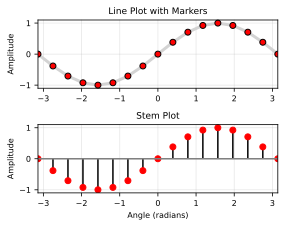

In [4]:
t_sparse = np.linspace(-np.pi, np.pi, 17)
f_sparse = np.sin(t_sparse)

plt.figure(figsize=(4, 3.2), layout='tight')

plt.subplot(2, 1, 1)
plt.plot(t_sparse, f_sparse, color='lightgray', linewidth=3,
         marker='o', markerfacecolor='red', markeredgecolor='black')
plt.title('Line Plot with Markers')
plt.ylabel('Amplitude')
plt.xlim(-np.pi, np.pi)
plt.ylim(-1.1, 1.1)
plt.grid(alpha=0.3)

plt.subplot(2, 1, 2)
plt.stem(t_sparse, f_sparse, linefmt='black', markerfmt='ro', basefmt='gray')
plt.title('Stem Plot')
plt.xlabel('Angle (radians)')
plt.ylabel('Amplitude')
plt.xlim(-np.pi, np.pi)
plt.ylim(-1.1, 1.1)
plt.grid(alpha=0.3)

Both panels represent exactly the same numerical values, but they emphasize different aspects of the data. The line plot highlights the overall shape while retaining the sampling positions through markers. The stem plot emphasizes the individual values and their relation to a common baseline, making it especially useful for discrete signals.

Matplotlib provides many other plot types for particular purposes. For example, `plt.scatter()` displays unrelated points, `plt.step()` holds each value until the next position, `plt.bar()` compares quantities using bars, `plt.hist()` visualizes a distribution, and `plt.errorbar()` adds uncertainty information. We will introduce such representations when they serve a specific purpose rather than attempting to memorize every plotting function here. An overview with executable examples is available in the official [Matplotlib plot types](https://matplotlib.org/stable/plot_types/index.html) documentation.

<a id="vis2D"></a>
## Visualizing Two-Dimensional Arrays

A line plot arranges values along a one-dimensional coordinate axis. Many numerical objects, however, are naturally organized in two dimensions. A digital image contains values at horizontal and vertical pixel positions, a table contains entries arranged in rows and columns, and a function of two variables may be evaluated on a rectangular grid. Matplotlib can visualize a two-dimensional NumPy array by representing each entry as a colored cell. The position of the cell corresponds to the row and column of the array, while its color represents the numerical value. The function `plt.imshow()` creates this color-coded representation, and `plt.colorbar()` adds a scale showing how the colors correspond to numerical values.

We begin with a small $3\times 8$ array `A` containing the integers from $0$ to $23$. Each colored square will represent one array entry. The horizontal axis shows the column index, while the vertical axis shows the row index. By default, row index `0` appears at the top, following the usual convention for displaying digital images.

The argument `cmap` selects the **colormap** used to translate numerical values into colors. In the selected colormap, smaller and larger values appear in different colors, whose numerical meaning can be read from the **colorbar**. The argument `interpolation='nearest'` keeps the individual cells clearly separated instead of visually smoothing the transitions between them. The following example illustrates these relationships between values, positions, and colors:

Array A:
[[ 0  1  2  3  4  5  6  7]
 [ 8  9 10 11 12 13 14 15]
 [16 17 18 19 20 21 22 23]]


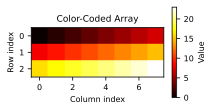

In [5]:
A = np.arange(24).reshape(3, 8)
print('Array A:', A, sep='\n')

plt.figure(figsize=(3.0, 1.6), layout='tight')
plt.imshow(A, cmap='hot', interpolation='nearest')
plt.colorbar(label='Value')
plt.title('Color-Coded Array')
plt.xlabel('Column index')
plt.ylabel('Row index');

The visualization does not change the array itself; it only determines how the array entries are displayed. Several parameters influence this visual representation:

* `cmap` selects the colormap used to represent the numerical values.
* `origin` determines whether the first row appears at the top or bottom.
* `aspect` controls the geometric proportions of the displayed cells. The default value `'equal'` keeps the cells square, while `'auto'` stretches the image to fill the available plotting area.

The appropriate settings depend on the meaning of the array. Digital images are commonly displayed with the first row at the top, while data associated with a Cartesian coordinate system are often easier to interpret with the origin at the lower left. The following three panels visualize exactly the same numerical array using different settings. Only its visual representation changes, reminding us that the appearance of a figure depends not only on the data but also on the selected plotting parameters:

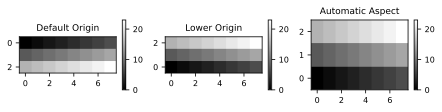

In [6]:
A = np.arange(24).reshape(3, 8)
plt.figure(figsize=(6.2, 1.6), layout='tight')

plt.subplot(1, 3, 1)
plt.imshow(A, cmap='gray', interpolation='nearest')
plt.colorbar()
plt.title('Default Origin')

plt.subplot(1, 3, 2)
plt.imshow(A, cmap='gray', origin='lower', interpolation='nearest')
plt.colorbar()
plt.title('Lower Origin')

plt.subplot(1, 3, 3)
plt.imshow(A, cmap='gray', origin='lower',
           aspect='auto', interpolation='nearest')
plt.colorbar()
plt.title('Automatic Aspect');

<a id="vis2D_details"></a>

## Coordinates, Display Limits, and Color Scaling

Displaying a two-dimensional array involves two separate mappings. The position of each array entry must be mapped to a location in the figure, and its numerical value must be mapped to a color. Matplotlib provides different parameters for controlling these aspects:

* `extent` assigns coordinate ranges to the displayed array.
* `plt.xlim()` and `plt.ylim()` select the visible coordinate region.
* `vmin` and `vmax` determine the numerical range represented by the colormap.

We begin with the spatial coordinates. So far, the axes have shown row and column indices. In many applications, however, these indices correspond to meaningful quantities such as time, frequency, distance, or spatial position. The argument `extent=[left, right, lower, upper]` assigns coordinate ranges to the horizontal and vertical axes without changing the underlying array.

For a more informative example, we evaluate the function $f(x,y)=\sin(3x)\cos(3y)\exp(-y^2)$ at discrete positions on a rectangular grid with $x\in[-2,3]$ and $y\in[-1,2]$. The function `np.meshgrid()` constructs the required coordinate matrices `X` and `Y`; we will discuss their structure and purpose more closely in the section on [three-dimensional surface plots](#vis3D). We also set one array entry to $1.3$, creating a clearly recognizable outlier that will help us identify the selected region when zooming into the figure.

The resulting array `A_wave` stores the values of $f$ on this grid and has shape `(31, 51)`. In the following visualization, the first subplot displays the array using column indices from `0` to `50` and row indices from `0` to `30`. In the second subplot, `extent` replaces these indices with the corresponding coordinate ranges, extending horizontally from $-2$ to $3$ and vertically from $-1$ to $2$. The values and shape of the array remain unchanged; only the coordinates used to display them are different:

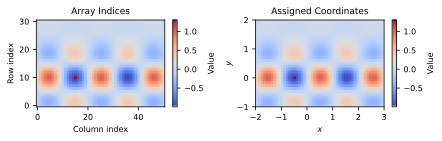

In [7]:
x = np.linspace(-2, 3, 51)   # Includes both endpoints by default
y = np.linspace(-1, 2, 31)
X, Y = np.meshgrid(x, y)
A_wave = np.sin(3 * X) * np.cos(3 * Y) * np.exp(-Y**2)
A_wave[10, 15] = 1.3
coordinate_extent = [x[0], x[-1], y[0], y[-1]]

plt.figure(figsize=(6.2, 2.0), layout='tight')

plt.subplot(1, 2, 1)
plt.imshow(A_wave, cmap='coolwarm', origin='lower',
           aspect='auto', interpolation='nearest')
plt.colorbar(label='Value')
plt.title('Array Indices')
plt.xlabel('Column index')
plt.ylabel('Row index')

plt.subplot(1, 2, 2)
plt.imshow(A_wave, cmap='coolwarm', origin='lower', aspect='auto',
           extent=coordinate_extent, interpolation='nearest')
plt.colorbar(label='Value')
plt.title('Assigned Coordinates')
plt.xlabel('$x$')
plt.ylabel('$y$');

The functions `plt.xlim()` and `plt.ylim()` select a smaller part of the displayed coordinate region, much like zooming into a figure. Their arguments always refer to the coordinates shown on the corresponding axes. When `extent` is specified, these are the assigned coordinates, such as $x\in[-2,3]$ and $y\in[-1,2]$ in this example. Without `extent`, the limits refer to column and row indices instead. In either case, only the visible region changes; the underlying array and its coordinate mapping remain unchanged:

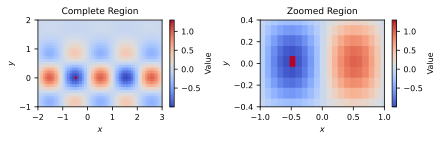

In [8]:
plt.figure(figsize=(6.2, 2.0), layout='tight')

plt.subplot(1, 2, 1)
plt.imshow(A_wave, cmap='coolwarm', origin='lower', aspect='auto',
           extent=coordinate_extent, interpolation='nearest')
plt.colorbar(label='Value')
plt.title('Complete Region')
plt.xlabel('$x$')
plt.ylabel('$y$')

plt.subplot(1, 2, 2)
plt.imshow(A_wave, cmap='coolwarm', origin='lower', aspect='auto',
           extent=coordinate_extent, interpolation='nearest')
plt.colorbar(label='Value')
plt.xlim(-1, 1)
plt.ylim(-0.4, 0.4)
plt.title('Zoomed Region')
plt.xlabel('$x$')
plt.ylabel('$y$');

The coordinate limits determine **where we look**, while the color limits determine **how the numerical values appear**. By default, Matplotlib maps the smallest and largest values of the complete array to the two ends of the colormap. An unusually large or small value may therefore reduce the visible contrast among the remaining values. The parameters `vmin` and `vmax` explicitly set the numerical color range. Values outside this range receive its endpoint colors. The following panels compare automatic scaling with a symmetric range from `-0.5` to `0.5`:

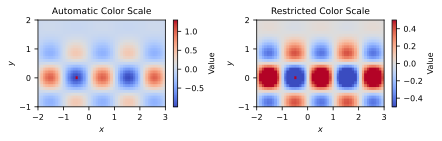

In [9]:
plt.figure(figsize=(6.2, 2.0), layout='tight')

plt.subplot(1, 2, 1)
plt.imshow(A_wave, cmap='coolwarm', origin='lower', aspect='auto',
           extent=coordinate_extent, interpolation='nearest')
plt.colorbar(label='Value')
plt.title('Automatic Color Scale')
plt.xlabel('$x$')
plt.ylabel('$y$')

plt.subplot(1, 2, 2)
plt.imshow(A_wave, cmap='coolwarm', origin='lower', aspect='auto',
           extent=coordinate_extent, interpolation='nearest',
           vmin=-0.5, vmax=0.5)
plt.colorbar(label='Value')
plt.title('Restricted Color Scale')
plt.xlabel('$x$')
plt.ylabel('$y$');

In the first panel, the complete value range of `A_wave`, including the outlier, determines the color scale. In the second, the symmetric limits place zero at the center of the diverging colormap and increase the visible contrast among values between $-0.5$ and $0.5$. The outlier, as well as every other value outside this interval, is represented using one of the endpoint colors. This improves contrast within the selected range but hides differences between values beyond its limits; the underlying array itself remains unchanged. When several arrays are compared, common values for `vmin` and `vmax` ensure that the same color represents the same numerical value in every panel. Otherwise, two identical colors may quietly mean two different things.

<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<p style="color:#E65100; margin-bottom:0;">
<strong>Note: A Plot Can Clarify or Mislead.</strong> A visualization is shaped not only by its data but also by choices such as axis limits, aspect ratios, colormaps, and color ranges. Narrow axis limits may exaggerate small differences, unequal scaling may make a circle appear elliptical, and independently chosen color limits may make arrays with very different values look deceptively similar. These effects are not necessarily errors, since each choice may be useful for a particular purpose. They should, however, be made deliberately and communicated through meaningful labels, units, tick marks, legends, and colorbars. <strong>A good scientific figure directs attention without quietly changing the meaning of what is shown.</strong>
</p>
</div>

<a id="vis3D"></a>
## Three-Dimensional Surface Plots

A two-dimensional array can represent values of a function with two input variables. In the preceding section, each value was represented by a color. Another possibility is to represent it as a height above the corresponding position in the coordinate plane, producing a **three-dimensional surface plot**. Such plots provide an intuitive view of peaks, valleys, oscillations, and isolated extreme values. Perspective may make exact numerical comparisons more difficult than in a color-coded image, so the two representations complement one another. Matplotlib supports several kinds of three-dimensional visualization. A three-dimensional plotting area is created by adding a subplot with `projection='3d'` to a figure. We focus on a surface plot here; further examples can be found in the [Matplotlib documentation on three-dimensional plotting](https://matplotlib.org/stable/users/explain/toolkits/mplot3d.html).

We continue with values of the function $f(x,y)=\sin(3x)\cos(3y)\exp(-y^2)$ sampled on the rectangular region $[-2,3]\times[-1,2]$, together with the additional outlier of value $1.3$. In the code, `x` contains 51 equally spaced coordinates, including both endpoints, and therefore divides an interval of length $5$ into 50 subintervals. Similarly, `y` contains 31 coordinates and divides an interval of length $3$ into 30 subintervals. The resulting spacing is $0.1$ in both directions, corresponding to ten grid intervals per coordinate unit. The one-dimensional arrays `x` and `y` contain the horizontal and vertical coordinates. The function `np.meshgrid()` expands them into the coordinate matrices `X` and `Y`. Each row of `X` contains the complete array `x`, while each column of `Y` contains the complete array `y`, giving both matrices the shape `(31, 51)`. At every index pair `(m, n)`, the values `X[m, n]` and `Y[m, n]` identify a point in the coordinate plane, while `A_wave[m, n]` provides its height. The following code repeats the construction for clarity and visualizes the same array as a surface:

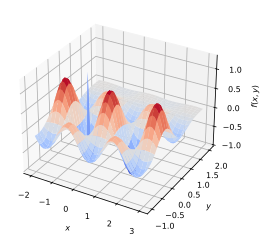

In [10]:
x = np.linspace(-2, 3, 51)   # Includes both endpoints by default
y = np.linspace(-1, 2, 31)
X, Y = np.meshgrid(x, y)

A_wave = np.sin(3 * X) * np.cos(3 * Y) * np.exp(-Y**2)
A_wave[10, 15] = 1.3

fig = plt.figure(figsize=(3.5, 3.5), layout='tight')
ax = fig.add_subplot(projection='3d')

ax.plot_surface(X, Y, A_wave, cmap='coolwarm', edgecolor='none')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_zlabel('$f(x,y)$');

Unlike `plt.imshow()`, `plot_surface()` receives the coordinate matrices `X` and `Y` directly. Each value in `A_wave` is therefore already associated with an explicit position in the coordinate plane, and no `extent` is required. Note that the inserted outlier is visible as a narrow peak, but its surrounding surface may not appear bright red even though $1.3$ is the largest individual value. A surface consists of small faces connecting neighboring grid points, and the color of each face is determined using several surrounding values. Since the positive outlier is surrounded by negative values, some adjacent faces may receive a bluish color. The height represents the individual value correctly, while the face color describes a small surface region rather than a single grid point. This illustrates a broader limitation of numerical visualization: the displayed result depends not only on the data but also on choices concerning discretization, interpolation, coloring, and rendering. A visualization is a computed representation of the data, not a neutral copy of them.

Many aspects of the visualization can be adjusted. The viewing direction can be changed with `ax.view_init(elev=..., azim=...)`, `cmap` selects the colormap, and parameters such as `edgecolor` and `alpha` control the appearance of the surface. In an interactive notebook environment, the figure may also be rotated with the mouse. Further parameters and examples can be found in the documentation for [`plot_surface()`](https://matplotlib.org/stable/api/_as_gen/mpl_toolkits.mplot3d.axes3d.Axes3D.plot_surface.html) and the [Matplotlib gallery of three-dimensional plots](https://matplotlib.org/stable/gallery/mplot3d/index.html).


<a id="exercise_vis1D"></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064; display:block; break-after:avoid; page-break-after:avoid;">Exercise 1: Visualizing a Sampled Sinusoid</strong>
<p style="color:#006064;">
This exercise combines the construction of a discrete time axis with the visualization of a sinusoidal signal. It also compares several plotting styles and the different impressions they create from the same numerical values.
</p>
<ul style="color:#006064;">
<li><strong>Construct the time axis:</strong> Create a NumPy array <code>t</code> covering the interval $[0,1]$ seconds with the sampling rate $F_{\mathrm{s}}=100\,\mathrm{Hz}$. The distance between neighboring sampling positions is therefore $1/F_{\mathrm{s}}=0.01$ seconds, giving <code>t[0] = 0</code>, <code>t[1] = 0.01</code>, and <code>t[-1] = 1</code>.</li>
<li><strong>Generate the signal:</strong> Evaluate the sinusoid $x(t)=\sin(2\pi\omega t)$ with frequency $\omega=5\,\mathrm{Hz}$ at the positions specified by <code>t</code>.</li>
<li><strong>Create a line plot:</strong> Plot <code>x</code> against <code>t</code>. Add the title <code>Sampled Sinusoid</code>, label the axes <code>Time (seconds)</code> and <code>Amplitude</code>, and display grid lines. Choose suitable values for <code>color</code>, <code>linewidth</code>, <code>linestyle</code>, and <code>marker</code>. Further options are listed in the documentation for <a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html"><code>plt.plot()</code></a>.</li>
<li><strong>Display one period:</strong> Determine the period $T=1/\omega$ and use <code>plt.xlim()</code> to display only the interval from $0$ to $T$.</li>
<li><strong>Compare plotting styles:</strong> Create a figure with four subplots showing the same samples from one period using a line plot with markers, <code>plt.stem()</code>, <code>plt.step()</code>, and <code>plt.bar()</code>. Use the same axis limits in every panel so that the representations can be compared fairly.</li>
<li><strong>Interpret the figures:</strong> Explain what each plotting style suggests about the values between the sampling positions. Which representations emphasize the individual samples, and which suggest continuous or piecewise-constant behavior?</li>
</ul>
</div>

In [11]:
# Your Solution

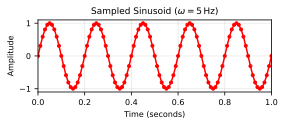

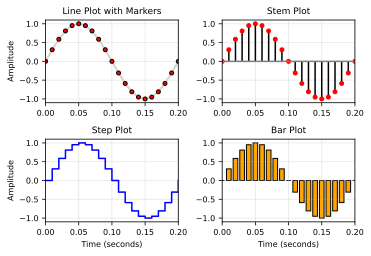

In [12]:
exercise_vis1D()

<a id="exercise_circle"></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">

<strong style="color:#006064; display:block; break-after:avoid; page-break-after:avoid;">
Exercise 2: Approximating a Circle with Samples
</strong>

<p style="color:#006064;">
A circle can be described using two functions of a common parameter. This exercise investigates how the number of sampled parameter values and the aspect ratio of the axes influence its visual representation. The example also prepares ideas that will return when studying complex exponentials and sampling.
</p>

<ul style="color:#006064;">
<li><strong>Construct the parameter axis:</strong> For a positive integer $F_{\mathrm{s}}\in\mathbb{N}$, create an array <code>t</code> containing $F_{\mathrm{s}}+1$ equally spaced values over the interval $[0,1]$, including both endpoints.</li>

<li><strong>Parameterize the circle:</strong> Consider the functions $f_1,f_2:[0,1]\to\mathbb{R}$ defined for $t\in[0,1]$ by $f_1(t):=\cos(2\pi t)$ and $f_2(t):=\sin(2\pi t)$. Evaluate both functions at the positions in <code>t</code> and store the results in the arrays <code>f1</code> and <code>f2</code>. Verify that $f_1(t)^2+f_2(t)^2=1$ and explain why every pair $(f_1(t),f_2(t))$ lies on the unit circle.</li>

<li><strong>Create the plot:</strong> Plot <code>f2</code> against <code>f1</code> using <code>plt.plot()</code>. Display the sampled positions using markers and connect neighboring points with lines.</li>

<li><strong>Preserve the geometry:</strong> Use <code>plt.axis('equal')</code> so that equal distances along the horizontal and vertical axes have equal visual lengths. Observe how the apparent shape may change when this setting is omitted.</li>

<li><strong>Write a reusable function:</strong> Implement <code>plot_circle(Fs, equal_aspect=True)</code>, which plots the sampled circle in the currently selected subplot. The parameter <code>equal_aspect</code> should determine whether equal scaling is used on both axes. Add suitable axis labels, limits, and grid lines.</li>

<li><strong>Compare sampling rates:</strong> Apply the function using $F_{\mathrm{s}}\in\{4,8,16,32\}$. Explain why the connected points initially form a clearly visible polygon and increasingly resemble a circle as the sampling rate grows.</li>
</ul>

</div>

In [13]:
# Your Solution

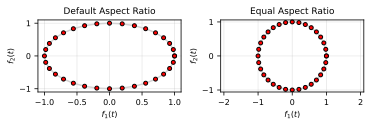

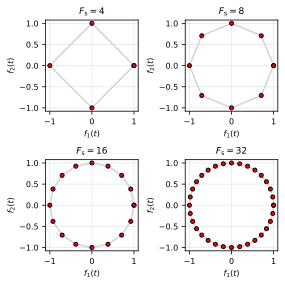

In [14]:
exercise_circle()

<a id="exercise_logaxis"></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064; display:block; break-after:avoid; page-break-after:avoid;">Exercise 3: Comparing Linear and Logarithmic Axes</strong>

<p style="color:#006064;">
This exercise considers the functions $f,g,h:[0,10]\to\mathbb{R}$ defined by $f(x):=\exp(x)$, $g(x):=x+0.1$, and $h(x):=\sin(10x)+1.1$ for $x\in[0,10]$. The horizontal axis represents the input $x$, while the vertical axis represents the corresponding function values. All displayed function values are positive and can therefore be shown on a logarithmic vertical axis.
</p>

<ul style="color:#006064;">
<li>Set <code>Fs = 100</code> and create <code>x = np.arange(1/Fs, 10 + 1/Fs, 1/Fs)</code>. The array begins at <code>1/Fs</code> rather than zero because a logarithmic horizontal axis can display only positive input values.</li>
<li>Store the values of $f$, $g$, and $h$ at the positions in <code>x</code> in the arrays <code>y_exp</code>, <code>y_linear</code>, and <code>y_oscillation</code>.</li>
<li>Create four subplots showing all three graphs. Use <code>plt.plot()</code>, <code>plt.semilogy()</code>, <code>plt.semilogx()</code>, and <code>plt.loglog()</code>. Use consistent colors and add titles, labels, legends, and grid lines.</li>
<li>Compare the four representations. Explain why the graph of $f$ becomes a straight line on a logarithmic vertical axis and how a logarithmic horizontal axis redistributes the input values.</li>
</ul>
</div>

In [15]:
# Your Solution

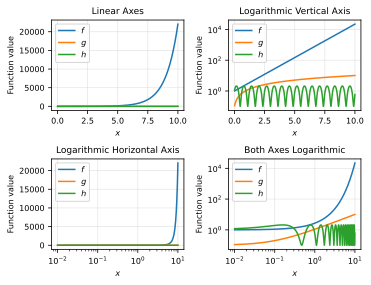

In [16]:
exercise_logaxis()

<a id="exercise_erlangen"></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">

<strong style="color:#006064; display:block; break-after:avoid; page-break-after:avoid;">
Exercise 4: Manipulating a Digital Photograph
</strong>

<div style="
  float:right;
  width:250px;
  max-width:40%;
  margin-top:8px;
  margin-left:20px;
  margin-bottom:10px;
">
<a href="https://de.wikipedia.org/wiki/Friedrich-Alexander-Universit%C3%A4t_Erlangen-N%C3%BCrnberg">
<img src="data/PCP_fig_erlangen.png"
     style="display:block; width:100%; height:auto;"
     alt="Photograph of Erlangen Palace">
</a>
</div>

<p style="color:#006064;">
A digital color image can be represented as a three-dimensional NumPy array. In this exercise, familiar array operations are used to modify a photograph of <a href="https://de.wikipedia.org/wiki/Markgr%C3%A4fliches_Schloss_Erlangen">Erlangen Palace</a>, a former margravial residence that later became the main administrative building of FAU.
</p>

<ul style="color:#006064;">
<li><strong>Load the image:</strong> Using <code>matplotlib.image</code>, which was imported as <code>mpimg</code>, load <code>'./data/PCP_fig_erlangen.png'</code> with <code>mpimg.imread()</code>. Store the resulting array as <code>image</code>.</li>

<li><strong>Inspect its representation:</strong> Display <code>image.shape</code> and verify that it is <code>(274, 400, 3)</code>. The first dimension contains the $274$ pixel rows, the second contains the $400$ pixel columns, and the third contains the red, green, and blue color channels.</li>

<li><strong>Display the photograph:</strong> Visualize the array using <code>plt.imshow()</code>. Add a title and examine how the axes correspond to the image’s rows and columns.</li>

<li><strong>Rotate the image:</strong> Use <code>np.rot90()</code> to rotate the photograph by $180^\circ$. Determine how many rotations by $90^\circ$ are required.</li>

<li><strong>Convert it to grayscale:</strong> Create a two-dimensional grayscale image by combining the three color channels. Display the result using <code>cmap='gray'</code>.</li>

<li><strong>Reveal intensity changes:</strong> Apply <code>np.diff()</code> to the grayscale image along the horizontal or vertical direction. Display the absolute differences and investigate how sudden changes in brightness can indicate edges.</li>

<li><strong>Experiment creatively:</strong> Produce another variation of the photograph. For example, exchange or suppress color channels, crop the image using array slicing, flip it, or combine several modifications. Remember that <code>cmap</code> affects the display of a two-dimensional array but does not recolor an RGB image.</li>

<li><strong>Save the result:</strong> Store one of your modified images in a variable named <code>image_modified</code> and save it using <code>mpimg.imsave('./output/PCP_fig_erlangen_mod.png', image_modified)</code>. The output directory must already exist.</li>

</ul>

<div style="clear:both;"></div>

<p style="color:#006064; margin-bottom:0;">
Photograph:
<a href="https://commons.wikimedia.org/wiki/File:Schloss-Erlangen02.JPG">Erlangen Palace</a>
by <a href="https://commons.wikimedia.org/wiki/User:Selby">Selby</a>,
licensed under
<a href="https://creativecommons.org/licenses/by-sa/3.0/">CC BY-SA 3.0</a>.
The image was resized for use in this notebook and is not covered by the notebook's MIT license.
</p>

</div>

In [17]:
# Your Solution

Image shape (rows, columns, channels): (274, 400, 3)


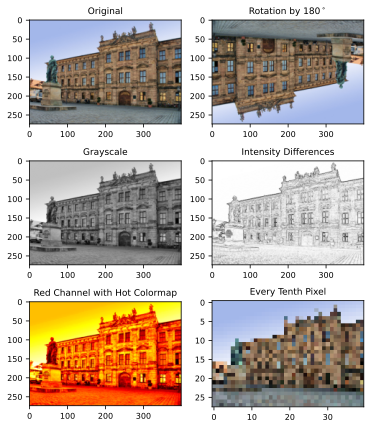

In [18]:
exercise_erlangen()

<div>
<a href="https://opensource.org/licenses/MIT"><img src="data_layout/PCP_License.png" width=100% style="float: right;" alt="PCP License"></a>
</div>